In [1]:
import os
from pathlib import Path
import pickle
from matplotlib import pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from glmhmm import *
from my_fun import fig_size, save_notebook_files

In [2]:
# Magics
%load_ext autoreload
%autoreload 2

In [3]:
# Plotting style
style_path = os.path.expanduser('~/PycharmProjects/alexis_style.mplstyle')
plt.style.use(style_path)
%config InlineBackend.figure_format = 'png'
# %config InlineBackend.figure_format = 'retina'
sns.set_style('ticks')
sns.set_context('notebook')

In [36]:
df = glue_groups(experiments=['2AFC_2', '2AFC_3', '2AFC_4'], path_session=f'glmhmm/TEST/2s_3cov')
df_null = glue_groups(experiments=['2AFC_2', '2AFC_3', '2AFC_4'], path_session='glmhmm/TEST/1s_null')

# Mean groups 2-4

Kept 20 / 25 subjects after column-wise IQR filtering
Covariate 0: t=11.354, p=0.0000
Covariate 1: t=-1.081, p=0.2932
Covariate 2: t=-8.488, p=0.0000


Text(0.5, 1, '2 states 3 covariates')

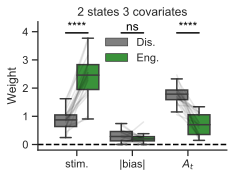

In [5]:
data = results_2_df(df)
figsize = fig_size(n_cols=2)
plot_paired_boxplot_GLMHMM_kernel(data, figsize=figsize, loc='upper center',  bbox_to_anchor=(0.5, 0.95))
plt.title('2 states 3 covariates')

array([[0.98100712, 0.01899288],
       [0.01432419, 0.98567581]])

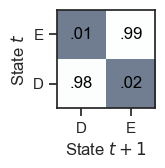

In [45]:
trans_mat = get_str_mat(df, col_name='TransMat')
figsize = (fig_size(n_cols=2)[0]/2, fig_size(n_cols=2)[0]/2)
plot_trans_mat(trans_mat, figsize=figsize)

State D occupancy: 0.37
State E occupancy: 0.63


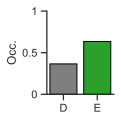

In [7]:
figsize = (fig_size(n_cols=2)[0]/2, fig_size(n_cols=2)[0]/2)
plot_occupancy(df, figsize=figsize)

0.44 ± 0.35 LL (bits/trial)


([], <a list of 0 Text xticklabel objects>)

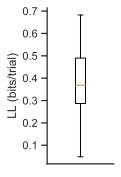

In [8]:
figsize = (fig_size(n_cols=2)[0]/2, fig_size(n_cols=2)[1])
plt.figure(figsize=figsize, constrained_layout=True)
ll_null = df_null.LogLikelihood.unique()
n_trials = df_null.groupby('Subject').size()
ll = df.LogLikelihood.unique()
plot_ll(ll, n_trials, ll_null=ll_null, to_bits=True, figsize=figsize)
plt.xlabel('')
plt.xticks([], [])

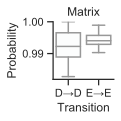

In [10]:
figsize = (fig_size(n_cols=2)[0]/2, fig_size(n_cols=2)[0]/2)
plot_trans_mat_box_plots(trans_mat, figsize=figsize)

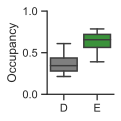

In [9]:
figsize = (fig_size(n_cols=2)[0]/2, fig_size(n_cols=2)[0]/2)
_ = plot_occupancy_boxplot(df, figsize=figsize)

# Group 2

Mice: [325 326 327 329 330 332 333 335 337]
Covariate 0: t=5.941, p=0.0003
Covariate 1: t=-0.912, p=0.3883
Covariate 2: t=-4.740, p=0.0015


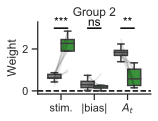

In [11]:
experiment = '2AFC_2'
figsize = fig_size(n_cols=3)
mask = data.Experiment == experiment
print(f'Mice: {data[mask].Animal.unique()}')
title = 'Group ' + experiment[-1]
ax = plot_paired_boxplot_GLMHMM_kernel(data[data.Experiment==experiment], title=title, figsize=figsize)
ax.legend_.remove()

# Group 3

Mice: [419 420 422 616 617 619 623]
Covariate 0: t=9.103, p=0.0001
Covariate 1: t=0.335, p=0.7490
Covariate 2: t=-8.737, p=0.0001


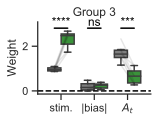

In [12]:
experiment = '2AFC_3'
figsize = fig_size(n_cols=3)
mask = data.Experiment == experiment
print(f'Mice: {data[mask].Animal.unique()}')
title = 'Group ' + experiment[-1]
ax = plot_paired_boxplot_GLMHMM_kernel(data[data.Experiment==experiment], title=title, figsize=figsize)
ax.legend_.remove()

# Group 4

Mice: [561 807 820 821]
Covariate 0: t=9.079, p=0.0028
Covariate 1: t=-1.224, p=0.3082
Covariate 2: t=-3.936, p=0.0292


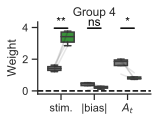

In [13]:
experiment = '2AFC_4'
figsize = fig_size(n_cols=3)
mask = data.Experiment == experiment
print(f'Mice: {data[mask].Animal.unique()}')
title = 'Group ' + experiment[-1]
ax = plot_paired_boxplot_GLMHMM_kernel(data[data.Experiment==experiment], title=title, figsize=figsize)
ax.legend_.remove()

# Group 6
Drug

In [42]:
summary = (
    df[['Subject', 'Date', 'Drug']]
    .drop_duplicates(['Subject', 'Date', 'Drug'])
    .sort_values(['Subject', 'Date', 'Drug'])
    .reset_index(drop=True)
)
summary

,Subject,Date,Drug
0,14,2025-07-15,0.0
1,14,2025-07-16,1.0
2,14,2025-08-07,0.0
3,14,2025-08-08,1.0
4,14,2025-08-11,0.0
...,...,...,...
157,25,2025-08-22,1.0
158,25,2025-08-25,0.0
159,25,2025-08-26,1.0
160,25,2025-09-01,0.0


## Rest
No injection sessions (no saline nor drug) were fitted separately

In [37]:
df_rest = glue_groups(experiments=['2AFC_6'], path_session=f'glmhmm/pharma/rest')

Covariate 0: t=4.623, p=0.0009
Covariate 1: t=-2.393, p=0.0378
Covariate 2: t=-4.312, p=0.0015


Text(0.5, 1, 'Rest')

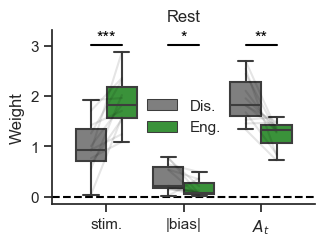

In [38]:
data_rest = results_2_df(df_rest)
figsize = fig_size(n_cols=2)
plot_paired_boxplot_GLMHMM_kernel(data_rest, figsize=figsize)
plt.title('Rest')

array([[0.98690703, 0.01309297],
       [0.00175038, 0.99824962]])

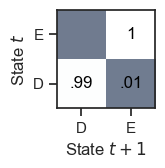

In [55]:
figsize = (fig_size(n_cols=2)[0]/2, fig_size(n_cols=2)[0]/2)
trans_mat_rest = get_str_mat(df_rest, col_name='TransMat')
plot_trans_mat(trans_mat_rest, figsize=figsize)

State D occupancy: 0.31
State E occupancy: 0.69


Text(0, 0.5, 'Occupancy')

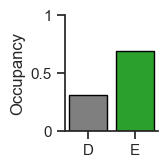

In [40]:
figsize = (fig_size(n_cols=2)[0]/2, fig_size(n_cols=2)[0]/2)
plot_occupancy(df_rest, figsize=figsize)
plt.ylabel('Occupancy')

State
Disengaged    0.306045
Engaged       0.693955
Name: Occupancy, dtype: float64


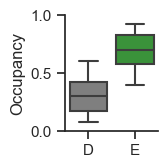

In [41]:
figsize = (fig_size(n_cols=2)[0]/2, fig_size(n_cols=2)[0]/2)
_ = plot_occupancy_boxplot(df_rest, figsize=figsize)

## Saline
Paired saline sessions were fitted separately

In [16]:
df_saline = glue_groups(experiments=['2AFC_6'], path_session=f'glmhmm/pharma/saline')

Covariate 0: t=3.564, p=0.0061
Covariate 1: t=-1.931, p=0.0855
Covariate 2: t=-3.097, p=0.0128


Text(0.5, 1, 'Saline')

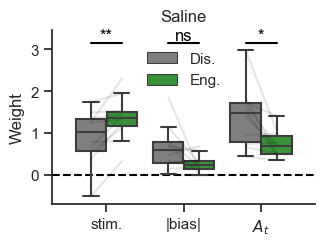

In [175]:
data_saline = results_2_df(df_saline)
figsize = fig_size(n_cols=2)
plot_paired_boxplot_GLMHMM_kernel(data_saline, figsize=figsize, loc='upper center', bbox_to_anchor=(0.5, 0.95))
plt.title('Saline')

array([[0.99469961, 0.00530039],
       [0.00430096, 0.99569904]])

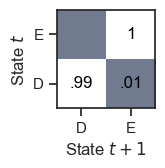

In [47]:
figsize = fig_size(n_cols=2)
figsize = (figsize[0]/2, figsize[0]/2)
trans_mat_saline = get_str_mat(df_saline, col_name='TransMat')
plot_trans_mat(trans_mat_saline, figsize=figsize)

State D occupancy: 0.44
State E occupancy: 0.56


Text(0, 0.5, 'Occupancy')

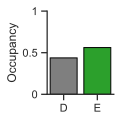

In [76]:
figsize = (fig_size(n_cols=2)[0]/2, fig_size(n_cols=2)[0]/2)
plot_occupancy(df_saline, figsize=figsize)
plt.ylabel('Occupancy')

State
Disengaged    0.437926
Engaged       0.562074
Name: Occupancy, dtype: float64


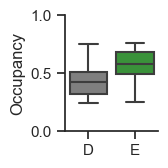

In [177]:
figsize = (fig_size(n_cols=2)[0]/2, fig_size(n_cols=2)[0]/2)
df_occ_saline = plot_occupancy_boxplot(df_saline, figsize=figsize)

## Drug
Paired drug sessions were fitted separately

In [21]:
df_drug = glue_groups(experiments=['2AFC_6'], path_session=f'glmhmm/pharma/drug')

Covariate 0: t=3.841, p=0.0040
Covariate 1: t=-1.907, p=0.0888
Covariate 2: t=-3.264, p=0.0098


Text(0.5, 1, 'Drug')

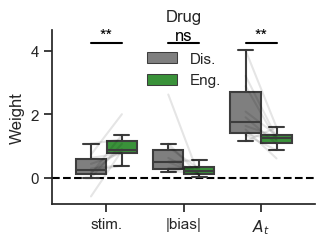

In [129]:
data_drug = results_2_df(df_drug)
figsize = fig_size(n_cols=2)
plot_paired_boxplot_GLMHMM_kernel(data_drug, figsize=figsize, loc='upper center', bbox_to_anchor=(0.5, 0.95))
plt.title('Drug')

array([[0.99478332, 0.00521668],
       [0.00336264, 0.99663736]])

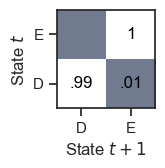

In [48]:
figsize = fig_size(n_cols=2)
figsize = (figsize[0]/2, figsize[0]/2)
trans_mat_drug = get_str_mat(df_drug, col_name='TransMat')
plot_trans_mat(trans_mat_drug, figsize=figsize)

State D occupancy: 0.41
State E occupancy: 0.59


Text(0, 0.5, 'Occupancy')

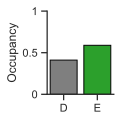

In [64]:
figsize = (fig_size(n_cols=2)[0]/2, fig_size(n_cols=2)[0]/2)
plot_occupancy(df_drug, figsize=figsize)
plt.ylabel('Occupancy')

State
Disengaged    0.411081
Engaged       0.588919
Name: Occupancy, dtype: float64


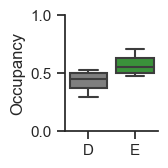

In [178]:
figsize = (fig_size(n_cols=2)[0]/2, fig_size(n_cols=2)[0]/2)
df_occ_drug = plot_occupancy_boxplot(df_drug, figsize=figsize)

## Combining saline and drug sessions fitted separately
Compare their weights between drug conditions for each state

In [26]:
# Combine saline and drug data DataFrames
data_saline['Drug'] = 0
data_drug['Drug'] = 1
data = pd.concat([data_saline, data_drug], ignore_index=True)

### Disengaged

Covariate 0: t=-7.123, p=0.0001
Covariate 1: t=0.273, p=0.7911
Covariate 2: t=2.995, p=0.0151


Text(0.5, 1, 'Disengaged')

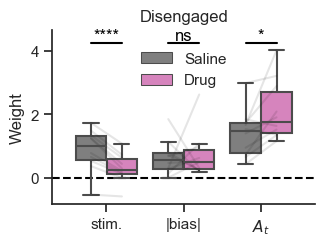

In [169]:
figsize = fig_size(n_cols=2)
ax = plot_paired_boxplot_GLMHMM_kernel(data[data.Label=='Disengaged'], drug=True, figsize=figsize, loc='upper center', bbox_to_anchor=(0.5, 0.95))
plt.title('Disengaged')

### Engaged

Covariate 0: t=-1.781, p=0.1085
Covariate 1: t=-0.527, p=0.6111
Covariate 2: t=2.945, p=0.0164


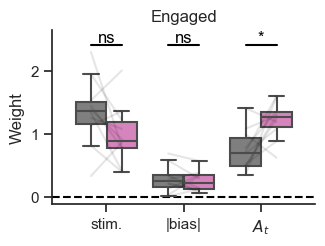

In [166]:
figsize = fig_size(n_cols=2)
ax = plot_paired_boxplot_GLMHMM_kernel(data[data.Label=='Engaged'], drug=True, figsize=figsize)
plt.title('Engaged')
ax.get_legend().remove()

t=-0.418, p=0.6857


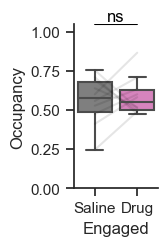

In [29]:
# Combine occupancy dataframes by state. So one df_engaged and one df_disengaged
df_occ_saline['Drug'] = 0
df_occ_drug['Drug'] = 1
df_occ = pd.concat([df_occ_saline, df_occ_drug], ignore_index=True)
figsize = fig_size(n_cols=2)
figsize = (figsize[0]/2, figsize[1])
plt.figure(figsize=figsize, constrained_layout=True)

# Engaged
y = 'Engaged'
sns.boxplot(data=df_occ, x='Drug', y='Engaged', palette=['tab:gray','tab:pink'], showfliers=False)
sns.lineplot(data=df_occ, x='Drug', y='Engaged', units='Subject', estimator=None, alpha=0.1, legend=False, color='k')

plt.xticks([0, 1], ['Saline','Drug'])
plt.ylim(0, 1.05)
plt.xlabel('Engaged')
plt.ylabel('Occupancy')
sns.despine()
p_saline = df_occ[df_occ.Drug==0]['Engaged']
p_drug = df_occ[df_occ.Drug==1]['Engaged']
t_stat, p_val = ttest_rel(p_saline, p_drug)
print(f't={t_stat:.3f}, p={p_val:.4f}')
add_star_between(p_val)

## Paired sessions
Saline-drug session pairs were fitted together

In [30]:
df_paired = glue_groups(experiments=['2AFC_6'], path_session=f'glmhmm/pharma/paired_sessions')

Covariate 0: t=5.472, p=0.0004
Covariate 1: t=-1.410, p=0.1922
Covariate 2: t=-4.005, p=0.0031


Text(0.5, 1, 'Paired sessions')

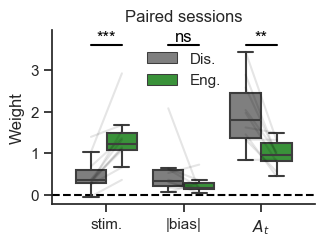

In [158]:
data_paired = results_2_df(df_paired)
figsize = fig_size(n_cols=2)
ax = plot_paired_boxplot_GLMHMM_kernel(data_paired, drug=False, figsize=figsize, loc='upper center', bbox_to_anchor=(0.5, 0.95))
plt.title('Paired sessions')

array([[0.99514834, 0.00485166],
       [0.0031643 , 0.9968357 ]])

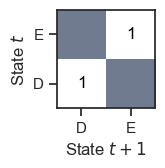

In [52]:
figsize = fig_size(n_cols=2)
figsize = (figsize[0]/2, figsize[0]/2)
trans_mat_paired = get_str_mat(df_paired, col_name='TransMat')
plot_trans_mat(trans_mat_paired, figsize=figsize)

State
Disengaged    0.250981
Engaged       0.749019
Name: Occupancy, dtype: float64
State
Disengaged    0.623003
Engaged       0.376997
Name: Occupancy, dtype: float64


Text(0.5, 1.0, 'Drug')

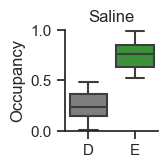

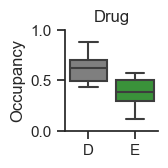

In [33]:
figsize = (fig_size(n_cols=2)[0]/2, fig_size(n_cols=2)[0]/2)
df_occ_saline = plot_occupancy_boxplot(df_paired[df_paired.Drug==0], figsize=figsize)
plt.title('Saline')
df_occ_drug = plot_occupancy_boxplot(df_paired[df_paired.Drug==1], figsize=figsize)
plt.title('Drug')

t=6.299, p=0.0001


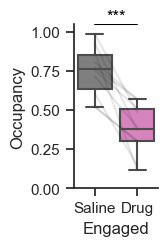

In [34]:
# Combine occupancy dataframes by state. So one df_engaged and one df_disengaged
df_occ_saline['Drug'] = 0
df_occ_drug['Drug'] = 1
df_occ = pd.concat([df_occ_saline, df_occ_drug], ignore_index=True)
figsize = fig_size(n_cols=2)
figsize = (figsize[0]/2, figsize[1])
plt.figure(figsize=figsize, constrained_layout=True)

# Engaged
y = 'Engaged'
sns.boxplot(data=df_occ, x='Drug', y='Engaged', palette=['tab:gray','tab:pink'], showfliers=False)
sns.lineplot(data=df_occ, x='Drug', y='Engaged', units='Subject', estimator=None, alpha=0.1, legend=False, color='k')

plt.xticks([0, 1], ['Saline','Drug'])
plt.ylim(0, 1.05)
plt.xlabel('Engaged')
plt.ylabel('Occupancy')
sns.despine()
p_saline = df_occ[df_occ.Drug==0]['Engaged']
p_drug = df_occ[df_occ.Drug==1]['Engaged']
t_stat, p_val = ttest_rel(p_saline, p_drug)
print(f't={t_stat:.3f}, p={p_val:.4f}')
add_star_between(p_val)

# Save all notebook's figures

In [30]:
# # Whole notebook outputs (no input or prompt, only Markdown and figures)
# # As HTML
# !jupyter nbconvert notebook.ipynb --to html --no-input --no-prompt
# # As PDF
# !jupyter nbconvert notebook.ipynb --to pdf --no-input --no-prompt
#
# Export all figures
# save_notebook_files(notebook_path='notebook_full_model.ipynb')